<a href="https://colab.research.google.com/github/abdhmohammadi/NLP/blob/main/Underestanding-Core-of-LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Probability Computation and Logits Analysis
**Date:** 2025-07-15


## 1. Initial 20 Sentences from a Reliable Source
We define a corpus of 20 sentences as our 'training vocabulary'.
For demonstration, these are manually selected general-purpose sentences.

In [ ]:
corpus =[
    "The quick brown fox jumps over the lazy dog",
    "She sells seashells by the seashore",
    "All that glitters is not gold",
    "To be or not to be that is the question",
    "I think therefore I am",
    "The only thing we have to fear is fear itself",
    "That's one small step for man one giant leap for mankind",
    "In the beginning God created the heaven and the earth",
    "It was the best of times it was the worst of times",
    "Call me Ishmael",
    "It is a truth universally acknowledged that a single man in possession of a good fortune must be in want of a wife",
    "May the Force be with you",
    "Elementary my dear Watson",
    "I have a dream that one day this nation will rise up",
    "Four score and seven years ago our fathers brought forth on this continent a new nation",
    "Ask not what your country can do for you ask what you can do for your country",
    "The only limit to our realization of tomorrow is our doubts of today",
    "Float like a butterfly sting like a bee",
    "The pen is mightier than the sword",
    "Knowledge is power"
]

## 2. Compute Classical Probability $P(w_1)$ for All Sentences



The code computes the probability of the first word of a sentence occurring in the corpus.
Let $C = \{s_1, s_2, \dots, s_{20}\}$ be the corpus of $20$ sentences.
Let $s_i = (w_{i,1}, w_{i,2}, \dots, w_{i, L_i})$ be the sequence of tokens in sentence $s_i$, where $L_i$ is the length of sentence $s_i$.

The code calculates the probability of each unique first token $w_1$ appearing in the corpus.
The set of all first tokens is $W_1 = \{w_{1,1}, w_{2,1}, \dots, w_{20,1}\}$.
The probability of a specific token $w$ being the first token is given by the empirical probability:
$P(w_1 = w) = \frac{\text{Number of sentences in } C \text{ that start with token } w}{N}$
In the code, this is computed in the below code cell.

In [ ]:
from collections import Counter
import pandas as pd

# Tokenizing each sentence and extracting first tokens
tokenized = [s.split() for s in corpus]
start_tokens = [tokens[0] for tokens in tokenized]

# Frequency counts
counts = Counter(start_tokens)
total = len(start_tokens)

# Prepare rows
first_words = list(counts.keys())
frequency_row = [counts[w] for w in first_words]
fraction_row = [f"{counts[w]}/{total}" for w in first_words]
probability_row = [round(counts[w] / total, 6) for w in first_words]

# Build final DataFrame
data = {
    "First Word": ["Frequency", "Fractional Probability", "Probability"]
}
for word in first_words:
    data[word] = [ counts[word], f"{counts[word]}/{total}", round(counts[word] / total, 6) ]

df = pd.DataFrame(data)

df.head()


,First Word,The,She,All,To,I,That's,In,It,Call,May,Elementary,Four,Ask,Float,Knowledge
0,Frequency,4,1,1,1,2,1,1,2,1,1,1,1,1,1,1
1,Fractional Probability,4/20,1/20,1/20,1/20,2/20,1/20,1/20,2/20,1/20,1/20,1/20,1/20,1/20,1/20,1/20
2,Probability,0.2,0.05,0.05,0.05,0.1,0.05,0.05,0.1,0.05,0.05,0.05,0.05,0.05,0.05,0.05


## 3. Classical Chain Probability for a Selected Sentence

In [ ]:
# Select a short sentence
sentence = "She sells seashells by the seashore"
tokens = sentence.split()
from collections import defaultdict, Counter
unigrams = Counter(); bigrams = Counter(); trigrams = Counter()
for tks in tokenized:
    for i, w in enumerate(tks):
        unigrams[w] += 1
        if i>0:
            bigrams[(tks[i-1], w)] += 1
        if i>1:
            trigrams[(tks[i-2], tks[i-1], w)] += 1
V = len(unigrams)
def prob_chain(tokens):
    probs = []
    for i, w in enumerate(tokens):
        if i == 0:
            p = unigrams[w] / total
        elif i == 1:
            p = (bigrams[(tokens[i-1], w)] + 1) / (unigrams[tokens[i-1]] + V)
        else:
            p = (trigrams[(tokens[i-2], tokens[i-1], w)] + 1) / (bigrams[(tokens[i-2], tokens[i-1])] + V)
        probs.append(p)
    return probs
chain_probs = prob_chain(tokens)
chain_probs

[0.05,
 0.016129032258064516,
 0.016129032258064516,
 0.016129032258064516,
 0.016129032258064516,
 0.016129032258064516]

## 4. Generate a New Short Sentence (Classical) with Explanations

In [ ]:
new_sentence = "Knowledge is power"
tokens_new = new_sentence.split()
probs_new = prob_chain(tokens_new)
list(zip(tokens_new, probs_new))

[('Knowledge', 0.05),
 ('is', 0.016129032258064516),
 ('power', 0.016129032258064516)]

## 5. Generating Logits \(z_i\) in Neural Network Methods
Neural networks compute logits via:
\[ z = W h_{t-1} + b \]

## 6. Compute Logits \(z_i\) for Selected Sentence using GPT-2

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()
inputs = tokenizer(sentence, return_tensors='pt')
with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits[0]
# Extract logits for each token
z_values = [None] + [logits[i-1, tokenizer.encode(tokens[i], add_special_tokens=False)[0]].item() for i in range(1, len(tokens))]
z_values

[None,
 -42.09275436401367,
 -103.57450103759766,
 -81.64705657958984,
 -98.16361999511719,
 -115.72769927978516]

## 7. Convert Logits \(z_i\) to Probabilities via Softmax

## 8. Bar Graphs for \(z_i\) and \(P(w_i)\)

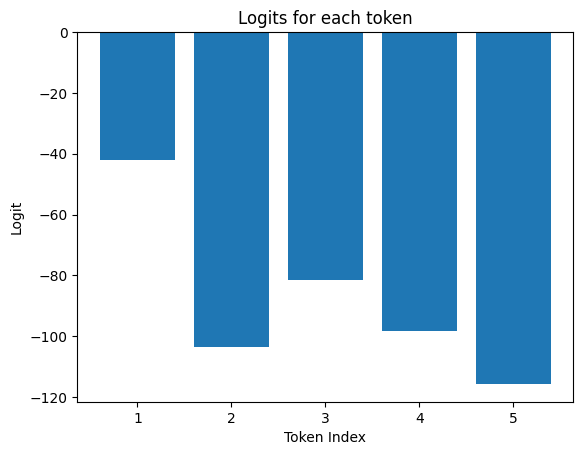

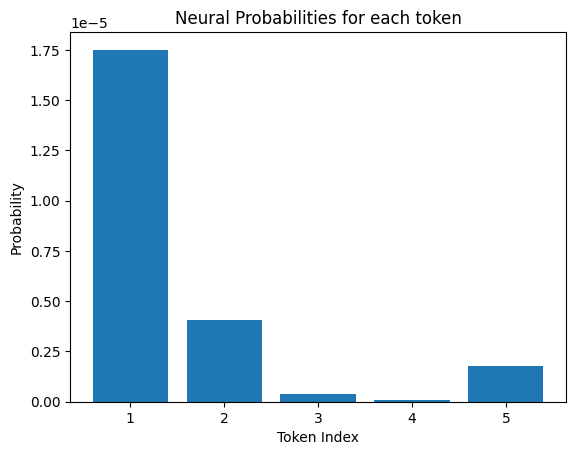

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Recalculate probs_nn in case the torch reinstall was necessary
probs_nn = []
for i in range(1, len(tokens)):
    probs_i = F.softmax(logits[i-1], dim=-1)
    token_id = tokenizer.encode(tokens[i], add_special_tokens=False)[0]
    probs_nn.append(probs_i[token_id].item())


plt.figure()
plt.bar(range(1, len(z_values)), z_values[1:])
plt.title('Logits for each token')
plt.xlabel('Token Index')
plt.ylabel('Logit')
plt.show()
plt.figure()
plt.bar(range(1, len(probs_nn)+1), probs_nn)
plt.title('Neural Probabilities for each token')
plt.xlabel('Token Index')
plt.ylabel('Probability')
plt.show()

## 9. Rationale for Neural Network Methods
Neural methods generalize better, provide smooth probabilities,
and handle data sparsity via learned representations.

## 10. Conclusion
We contrasted traditional and neural methods, showing chain probabilities and logits conversion via softmax.

## 11. References
- Goodfellow et al., *Deep Learning*, MIT Press, 2016
- Vaswani et al., *Attention is All You Need*, NeurIPS 2017
- Radford et al., *Language Models are Unsupervised Multitask Learners*, OpenAI, 2019
- Papoulis & Pillai, *Probability, Random Variables and Stochastic Processes*, 2002